# card2vec: Learning Dense Card Embeddings for Pokémon TCG
# card2vec: ポケモンTCGのカード埋め込み学習

---

**EN:** This notebook introduces **card2vec**, an AutoEncoder-based approach to represent each Pokémon TCG card as a 64-dimensional dense vector. The goal is to enable reinforcement learning agents to generalize across cards — including cards unseen during training — by encoding their attributes rather than treating them as opaque IDs.

**JP:** このノートブックでは、ポケモンTCGの各カードを64次元の密なベクトルとして表現する **card2vec** を紹介します。カードをIDとして扱うのではなく、属性をエンコードすることで、強化学習エージェントが未学習カードにも対応できるよう汎化性能を高めることが目的です。

---

> ⏱️ **Runtime:** Sections 1–8 complete in under **1 minute on CPU**. Sections 9 and beyond (added based on comments) additionally require parsing battle log data, which may take longer depending on the number of episodes available.  
> ⏱️ **実行時間:** セクション1〜8は **CPUのみで1分以内**に完了します。コメントに基づき追記いたしましたセクション9以降は、バトルログのパースが追加で必要となり、エピソード数によっては時間がかかる場合があります。

> 💬 **I'm relatively new to Kaggle and not very confident in my ML knowledge. If you spot any mistakes or have suggestions, please let me know in the comments — discussion is very welcome!**  
> 💬 **KaggleもMLもまだ勉強中です。設計の判断に自信のない部分も多いので、気になった点や改善のアイデアがあればぜひコメントで教えてください！**

> 🤖 **Note:** This notebook was created with the assistance of [Claude Code](https://claude.ai/code), Anthropic's AI coding agent.  
> 🤖 **注記:** このノートブックは、AnthropicのAIコーディングエージェント [Claude Code](https://claude.ai/code) の支援を受けて作成されました。

---

## Table of Contents / 目次

1. [Motivation / 動機](#motivation)
2. [Data Exploration / データ探索](#data-exploration)
3. [Feature Engineering / 特徴量設計](#feature-engineering)
4. [AutoEncoder Architecture / モデル構造](#model)
5. [Training / 学習](#training)
6. [Embedding Visualization / 埋め込みの可視化](#visualization)
7. [Usage in RL Agent / RLエージェントへの組み込み](#usage)
8. [Conclusion / まとめ](#conclusion)
9. [Improvements: Regularization & Weighted Loss](#v2) *(added based on comments)*
10. [Co-occurrence Embedding / 共起ベース埋め込み](#w2v) *(added based on comments)*
11. [Summary / まとめ（全手法比較）](#summary) *(added based on comments)*

<a id='motivation'></a>
## 1. Motivation / 動機

### EN

In the standard reinforcement learning baseline, each card is identified by its integer ID. This has two major drawbacks:

1. **No generalization to unseen cards.** If a card never appears in training games, the agent has no representation for it at all.
2. **No semantic structure.** Card IDs are arbitrary — ID 42 and ID 43 could be completely unrelated cards, while ID 42 and ID 500 might be strategically similar. The agent cannot exploit these relationships.

**card2vec** addresses both issues by representing each card as a dense vector derived from its actual attributes: HP, type, attack cost, damage, ability keywords, etc. Cards with similar attributes will have similar vectors, allowing the RL agent to transfer knowledge across similar cards.

### JP

標準的なRLベースラインでは、各カードは整数IDで識別されます。これには2つの大きな問題があります：

1. **未学習カードへの汎化不可。** 学習中に一度も登場しなかったカードに対して、エージェントは何の表現も持てません。
2. **意味的な構造がない。** カードIDは任意の番号であり、ID 42とID 43が全く無関係なカードである一方、ID 42とID 500が戦略的に似たカードであることもあります。エージェントはこのような関係を活用できません。

**card2vec** は、HP・タイプ・攻撃コスト・ダメージ・アビリティキーワードなど実際の属性から各カードを密なベクトルとして表現することで、両方の問題を解決します。似た属性を持つカードは似たベクトルを持つため、RLエージェントは類似カード間で知識を転用できます。

## Setup / セットアップ

In [1]:
import csv
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Kaggle environment detection
import os

import glob
csv_candidates = glob.glob("/kaggle/input/**/EN_Card_Data.csv", recursive=True)
CSV_PATH = Path(csv_candidates[0]) if csv_candidates else Path("EN_Card_Data.csv")


print(f"CSV path: {CSV_PATH}")
print(f"CSV exists: {CSV_PATH.exists()}")
print(f"PyTorch version: {torch.__version__}")

CSV path: /kaggle/input/competitions/pokemon-tcg-ai-battle/EN_Card_Data.csv
CSV exists: True
PyTorch version: 2.10.0+cpu


<a id='data-exploration'></a>
## 2. Data Exploration / データ探索

**EN:** Let's first understand the structure of the card data. The CSV contains one row per move — cards with two attacks appear as two rows with the same Card ID.

**JP:** まずカードデータの構造を確認します。CSVはワザごとに1行となっており、2つのワザを持つカードは同じCard IDで2行存在します。

In [2]:
with open(CSV_PATH, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    all_rows = list(reader)

unique_ids = set(r["Card ID"] for r in all_rows)
print(f"Total rows     / 総行数       : {len(all_rows)}")
print(f"Unique cards   / ユニークカード数: {len(unique_ids)}")
print(f"Multi-move cards / 複数ワザカード: {len(all_rows) - len(unique_ids)}")
print()
print("Columns / カラム:")
for col in all_rows[0].keys():
    print(f"  - {col}")

Total rows     / 総行数       : 2022
Unique cards   / ユニークカード数: 1267
Multi-move cards / 複数ワザカード: 755

Columns / カラム:
  - Card ID
  - Card Name
  - Expansion
  - Collection No.
  - Stage (Pokémon)/Type (Energy and Trainer)
  - Rule
  - Category
  - Previous stage
  - HP
  - Type
  - Weakness
  - Resistance (Type)
  - Retreat
  - Move Name
  - Cost
  - Damage
  - Effect Explanation


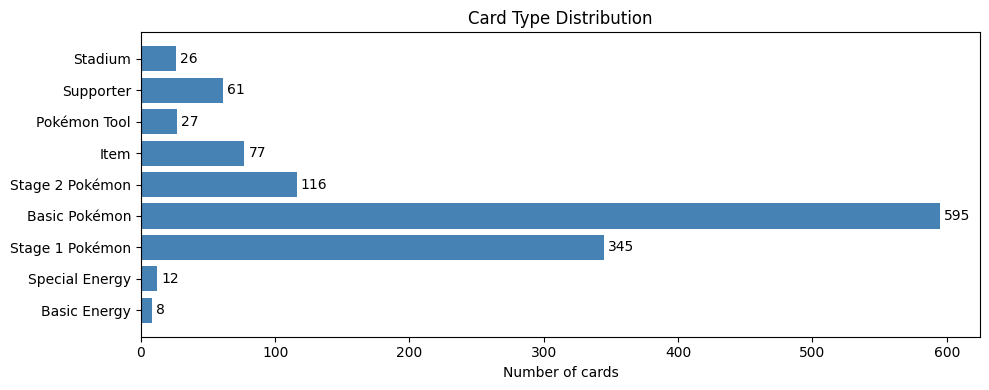

In [3]:
# Card type distribution / カード種類の分布
stage_counts = defaultdict(int)
seen_ids = set()
for r in all_rows:
    if r["Card ID"] not in seen_ids:
        stage_counts[r["Stage (Pokémon)/Type (Energy and Trainer)"]] += 1
        seen_ids.add(r["Card ID"])

labels = list(stage_counts.keys())
values = [stage_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, values, color="steelblue")
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of cards")
ax.set_title("Card Type Distribution")
plt.tight_layout()
plt.show()

In [4]:
# Sample: a Pokémon card with two moves / 2ワザを持つポケモンカードのサンプル
card_rows_map = defaultdict(list)
for r in all_rows:
    card_rows_map[r["Card ID"]].append(r)

two_move_id = next(cid for cid, rows in card_rows_map.items() if len(rows) == 2)
print(f"Sample card (2 moves) / 2ワザカードのサンプル: ID={two_move_id}")
sample = card_rows_map[two_move_id]
print(f"  Name: {sample[0]['Card Name']}")
print(f"  Stage: {sample[0]['Stage (Pokémon)/Type (Energy and Trainer)']}")
print(f"  HP: {sample[0]['HP']}")
print(f"  Type: {sample[0]['Type']}")
print(f"  Weakness: {sample[0]['Weakness']}")
print(f"  Retreat: {sample[0]['Retreat']}")
for i, row in enumerate(sample):
    print(f"  Move {i+1}: {row['Move Name']} | Cost: {row['Cost']} | Damage: {row['Damage']}")
    if row['Effect Explanation'] and row['Effect Explanation'] != 'n/a':
        print(f"    Effect: {row['Effect Explanation'][:100]}")

Sample card (2 moves) / 2ワザカードのサンプル: ID=21
  Name: Scrafty
  Stage: Stage 1 Pokémon
  HP: 120
  Type: {D}
  Weakness: {G}
  Retreat: 1
  Move 1: Nab ’n’ Dash | Cost: ● | Damage: n/a
    Effect: Search your deck for a number of cards up to the number of your Benched Pokémon and put them into yo
  Move 2: High Jump Kick | Cost: {D}●● | Damage: 100


<a id='feature-engineering'></a>
## 3. Feature Engineering / 特徴量設計

### EN

We encode each card into a **148-dimensional float vector** where all values lie in `[0, 1]`. This makes it compatible with the `BCELoss` used for training the AutoEncoder.

The feature vector is composed of:

| Feature | Dims | Encoding |
|---|---|---|
| Card type (Basic/Stage1/Item/...) | 9 | one-hot |
| Rule (ex / Mega ex / ACE SPEC) | 4 | one-hot |
| Category (Ancient / Future / Tera / ...) | 7 | one-hot |
| HP | 1 | normalized (max=380) |
| Pokémon type | 11 | one-hot + none |
| Weakness | 11 | one-hot + none |
| Retreat cost | 1 | normalized (max=4) |
| Move 1: energy cost | 11 | per-type ratio |
| Move 1: damage | 1 | normalized (max=400) |
| Move 1: effect keywords | 40 | binary |
| Move 2: energy cost | 11 | (zero if no Move 2) |
| Move 2: damage | 1 | |
| Move 2: effect keywords | 40 | |
| **Total** | **148** | |

**Effect text as keywords:** General-purpose text models like BERT do not handle Pokémon TCG-specific vocabulary (damage counters, retreat, bench, etc.) well. Instead, we use the presence/absence of 40 TCG-relevant keywords as binary features, capturing the strategic essence of each effect at low cost.

**Energy cost normalization:** The cost string (e.g. `{R}{R}●`) is converted to per-type counts and divided by the total cost, yielding a normalized ratio of energy composition.

### JP

各カードを **148次元の浮動小数点ベクトル** にエンコードします。全値が `[0, 1]` の範囲に収まるよう設計されており、AutoEncoderの学習に使う `BCELoss` と相性が良い構造です。

**効果テキストのキーワード化:** BERTのような汎用テキストモデルは、ポケモンTCG固有の語彙（ダメカン、にげる、ベンチ等）を十分に理解できません。そこで、TCGに関連する40種類のキーワードの有無をbinary featureとして使います。これにより効果の戦略的な要点を低コストで捉えられます。

**エネルギーコストの正規化:** コスト文字列（例: `{R}{R}●`）を各エネルギータイプのカウントに変換し、合計コストで割ることで「エネルギーの内訳の比率」として正規化します。

In [5]:
# Feature constants / 特徴量定数

CARD_TYPES = [
    "Basic Energy", "Special Energy", "Basic Pokémon", "Stage 1 Pokémon",
    "Stage 2 Pokémon", "Item", "Supporter", "Stadium", "Pokémon Tool",
]
RULES = ["n/a", "Pokémon ex", "Mega Pokémon ex", "ACE SPEC"]
CATEGORIES = ["n/a", "Ancient", "Future", "Tera", "Trainer's Pokémon", "Technical Machine", "Fossil"]
ENERGY_TYPES = ["{G}", "{R}", "{W}", "{L}", "{P}", "{F}", "{D}", "{M}", "{Y}", "{N}", "●"]
POKEMON_TYPES = ["{G}", "{R}", "{W}", "{L}", "{P}", "{F}", "{D}", "{M}", "{Y}", "{N}"]

EFFECT_KEYWORDS = [
    "draw", "search your deck", "discard", "bench", "retreat", "switch",
    "damage counter", "poison", "burn", "paralyzed", "confused", "asleep",
    "flip a coin", "heads", "tails",
    "heal", "remove damage",
    "attach", "energy",
    "evolve", "knock out",
    "active spot", "benched pokémon",
    "can't attack", "can't retreat",
    "during your next turn", "opponent's next turn",
    "prize", "extra prize",
    "shuffle", "look at the top",
    "your hand", "opponent's hand",
    "both active pokémon",
    "leave the active spot",
    "ancient", "future",
    "rule box",
    "special condition",
    "ability",
]

MAX_HP = 380.0
MAX_RETREAT = 4.0
MAX_DAMAGE = 400.0
FEATURE_DIM = 148

print(f"CARD_TYPES   : {len(CARD_TYPES)} classes")
print(f"RULES        : {len(RULES)} classes")
print(f"CATEGORIES   : {len(CATEGORIES)} classes")
print(f"EFFECT_KEYWORDS: {len(EFFECT_KEYWORDS)} keywords")
print(f"Total feature dim: {len(CARD_TYPES) + len(RULES) + len(CATEGORIES) + 1 + (len(POKEMON_TYPES)+1)*2 + 1 + (len(ENERGY_TYPES)+1+len(EFFECT_KEYWORDS))*2}")

CARD_TYPES   : 9 classes
RULES        : 4 classes
CATEGORIES   : 7 classes
EFFECT_KEYWORDS: 40 keywords
Total feature dim: 148


In [6]:
# Feature extraction functions / 特徴量抽出関数

def _normalize_category(raw: str) -> str:
    if raw.startswith("Tera"):
        return "Tera"
    if raw.startswith("Trainer's Pokémon"):
        return "Trainer's Pokémon"
    return raw if raw in CATEGORIES else "n/a"


def _one_hot_exact(value: str, classes: list) -> list:
    vec = [0.0] * len(classes)
    if value in classes:
        vec[classes.index(value)] = 1.0
    return vec


def _one_hot(value: str, classes: list) -> list:
    """one-hot with extra 'none' slot at the end"""
    vec = [0.0] * (len(classes) + 1)
    if value in classes:
        vec[classes.index(value)] = 1.0
    else:
        vec[-1] = 1.0
    return vec


def _parse_energy_cost(cost_str: str) -> list:
    counts = [0.0] * len(ENERGY_TYPES)
    if not cost_str or cost_str == "n/a":
        return counts
    for token in re.findall(r"\{[A-Z]\}|●", cost_str):
        if token in ENERGY_TYPES:
            counts[ENERGY_TYPES.index(token)] += 1.0
    total = sum(counts)
    return [c / total for c in counts] if total > 0 else counts


def _keyword_features(text: str) -> list:
    t = text.lower() if text and text != "n/a" else ""
    return [1.0 if kw in t else 0.0 for kw in EFFECT_KEYWORDS]


def extract_features(card_rows: list) -> np.ndarray:
    first = card_rows[0]
    f = []
    f.extend(_one_hot_exact(first.get("Stage (Pokémon)/Type (Energy and Trainer)", ""), CARD_TYPES))
    f.extend(_one_hot_exact(first.get("Rule", "n/a"), RULES))
    f.extend(_one_hot_exact(_normalize_category(first.get("Category", "n/a")), CATEGORIES))
    hp = first.get("HP", "")
    f.append(float(hp) / MAX_HP if hp and hp != "n/a" else 0.0)
    f.extend(_one_hot(first.get("Type", ""), POKEMON_TYPES))
    f.extend(_one_hot(first.get("Weakness", ""), POKEMON_TYPES))
    retreat = first.get("Retreat", "")
    f.append(float(retreat) / MAX_RETREAT if retreat and retreat != "n/a" else 0.0)
    for move_idx in range(2):
        if move_idx < len(card_rows):
            row = card_rows[move_idx]
            f.extend(_parse_energy_cost(row.get("Cost", "")))
            dmg = row.get("Damage", "")
            dmg_clean = re.sub(r"[^0-9]", "", dmg) if dmg and dmg != "n/a" else ""
            f.append(float(dmg_clean) / MAX_DAMAGE if dmg_clean else 0.0)
            f.extend(_keyword_features(row.get("Effect Explanation", "")))
        else:
            f.extend([0.0] * (11 + 1 + len(EFFECT_KEYWORDS)))
    return np.array(f, dtype=np.float32)


print("Functions defined. / 関数定義完了")

# Verify feature dim / 特徴量次元の確認
sample_feature = extract_features(card_rows_map[two_move_id])
print(f"Feature vector shape: {sample_feature.shape}  (expected: {FEATURE_DIM})")

Functions defined. / 関数定義完了
Feature vector shape: (148,)  (expected: 148)


In [7]:
# Build full feature matrix / 全カードの特徴量行列を構築
card_ids = sorted(card_rows_map.keys(), key=int)
feature_matrix = np.stack([extract_features(card_rows_map[cid]) for cid in card_ids])

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Value range: [{feature_matrix.min():.3f}, {feature_matrix.max():.3f}]")
print(f"Non-zero ratio: {(feature_matrix > 0).mean():.3f}")

Feature matrix shape: (1267, 148)
Value range: [0.000, 1.000]
Non-zero ratio: 0.077


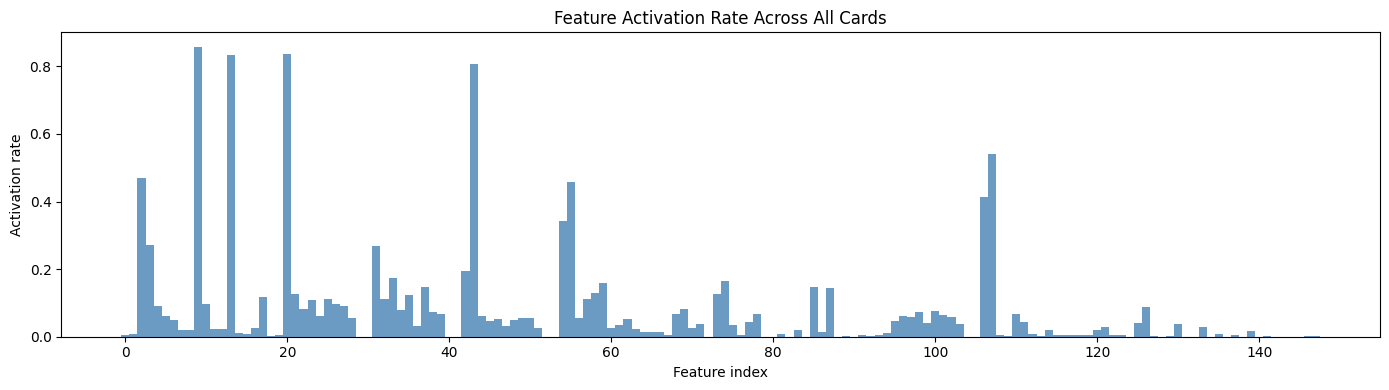

In [8]:
# Feature sparsity visualization / 特徴量のスパース性の可視化
feature_names = (
    [f"type:{t}" for t in CARD_TYPES] +
    [f"rule:{r}" for r in RULES] +
    [f"cat:{c}" for c in CATEGORIES] +
    ["hp"] +
    [f"pktype:{t}" for t in POKEMON_TYPES] + ["pktype:none"] +
    [f"weak:{t}" for t in POKEMON_TYPES] + ["weak:none"] +
    ["retreat"] +
    [f"mv1_cost:{t}" for t in ENERGY_TYPES] +
    ["mv1_dmg"] +
    [f"mv1_kw:{kw[:12]}" for kw in EFFECT_KEYWORDS] +
    [f"mv2_cost:{t}" for t in ENERGY_TYPES] +
    ["mv2_dmg"] +
    [f"mv2_kw:{kw[:12]}" for kw in EFFECT_KEYWORDS]
)

activation_rate = (feature_matrix > 0).mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(FEATURE_DIM), activation_rate, width=1.0, color="steelblue", alpha=0.8)
ax.set_xlabel("Feature index")
ax.set_ylabel("Activation rate")
ax.set_title("Feature Activation Rate Across All Cards")
plt.tight_layout()
plt.show()

<a id='model'></a>
## 4. AutoEncoder Architecture / モデル構造

### EN

The AutoEncoder compresses a 148-dim feature vector into a 64-dim latent vector and reconstructs it back:

```
Input (148) → Linear(148→128) → ReLU → Linear(128→64) → ReLU  →  Latent (64)
                                                                         ↓
Output (148) ← Sigmoid ← Linear(128→148) ← ReLU ← Linear(64→128)
```

- **Sigmoid** on the output ensures all reconstructed values are in `[0, 1]`, matching the input range.
- **BCELoss** (Binary Cross-Entropy) is used as the reconstruction loss. It works well for this mixed binary/continuous feature space.
- **Total parameters: ~55,000** — extremely lightweight; trains in seconds on a MacBook CPU.

### JP

AutoEncoderは148次元の特徴量ベクトルを64次元の潜在ベクトルに圧縮し、再構成します：

- 出力層の **Sigmoid** により再構成値が `[0, 1]` に収まり、入力の範囲と一致します。
- 損失関数には **BCELoss**（Binary Cross-Entropy）を使用。binary/連続値が混在する特徴量空間に適しています。
- **総パラメータ数: 約55,000** — 非常に軽量で、MacBookのCPUで数十秒で学習できます。

In [9]:
LATENT_DIM = 64


class CardAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(FEATURE_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, LATENT_DIM),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, FEATURE_DIM),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = CardAutoEncoder()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters / 総パラメータ数: {total_params:,}")
print()
print(model)

Total parameters / 総パラメータ数: 54,740

CardAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=148, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=148, bias=True)
    (3): Sigmoid()
  )
)


<a id='training'></a>
## 5. Training / 学習

**EN:** We train the AutoEncoder to reconstruct the input feature vectors. The encoder part learns to extract the most important information into 64 dimensions.

**JP:** AutoEncoderを入力特徴量ベクトルの再構成で学習します。エンコーダ部分が最も重要な情報を64次元に圧縮することを学習します。

In [10]:
EPOCHS = 200
BATCH_SIZE = 64
LR = 1e-3

tensor = torch.from_numpy(feature_matrix)
dataset = TensorDataset(tensor)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = CardAutoEncoder()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for (batch,) in loader:
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)
    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3d}/{EPOCHS}  Loss: {avg_loss:.6f}")

print(f"\nFinal loss / 最終Loss: {loss_history[-1]:.6f}")

Epoch   1/200  Loss: 0.624206
Epoch  20/200  Loss: 0.092622
Epoch  40/200  Loss: 0.038744
Epoch  60/200  Loss: 0.024268
Epoch  80/200  Loss: 0.018783
Epoch 100/200  Loss: 0.016130
Epoch 120/200  Loss: 0.014845
Epoch 140/200  Loss: 0.014027
Epoch 160/200  Loss: 0.013639
Epoch 180/200  Loss: 0.013363
Epoch 200/200  Loss: 0.013172

Final loss / 最終Loss: 0.013172


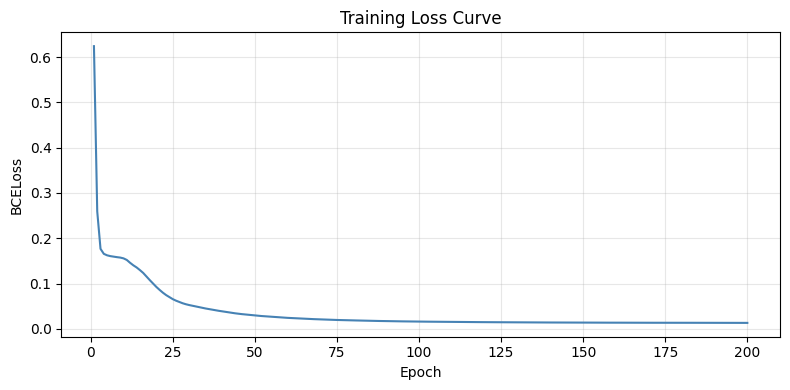

In [11]:
# Training loss curve / 学習曲線
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), loss_history, color="steelblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCELoss")
ax.set_title("Training Loss Curve")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Saving Embeddings / 埋め込みの保存

**EN:** Embeddings are saved in two formats:
- `embeddings.pt` — `dict[int → Tensor(64,)]`, keyed by card ID
- `embeddings_tensor.pt` — dense `Tensor(1268, 64)` where **row index = card ID**

Note that `embeddings_tensor.pt` has shape `(1268, 64)` — one row larger than the number of unique cards (1267) — because **index 0 is reserved as a null/padding vector** (all zeros). This allows direct O(1) lookup by card ID with no offset arithmetic.

**JP:** 埋め込みを2つの形式で保存します：
- `embeddings.pt` — `dict[int → Tensor(64,)]`、card IDをキーとする辞書形式
- `embeddings_tensor.pt` — dense `Tensor(1268, 64)`、**行インデックス = card ID**

`embeddings_tensor.pt` のshapeは `(1268, 64)` で、ユニークカード数（1267）より1大きい点に注意してください。これは **index 0をnull/paddingベクトル（ゼロベクトル）として予約**しているためです。card_idをそのままインデックスとして使えるO(1)参照が可能になります。

In [12]:
# Extract embeddings / 埋め込みを抽出
model.eval()
with torch.no_grad():
    embeddings = model.encoder(tensor).numpy()

print(f"Embeddings shape: {embeddings.shape}")
print(f"Value range: [{embeddings.min():.3f}, {embeddings.max():.3f}]")

Embeddings shape: (1267, 64)
Value range: [0.000, 28.544]


In [13]:
# Save embeddings / 埋め込みを保存
# Keys are int (card_id). Index 0 is reserved as null/padding (zero vector).
OUTPUT_DIR = Path(".")

int_card_ids = [int(cid) for cid in card_ids]
embedding_dict = {cid: torch.from_numpy(embeddings[i]) for i, cid in enumerate(int_card_ids)}
torch.save(embedding_dict, OUTPUT_DIR / "embeddings.pt")

max_id = max(embedding_dict.keys())
dense = torch.zeros(max_id + 1, LATENT_DIM)
for cid, emb in embedding_dict.items():
    dense[cid] = emb
torch.save(dense, OUTPUT_DIR / "embeddings_tensor.pt")

torch.save(model.state_dict(), OUTPUT_DIR / "card_autoencoder.pth")

print(f"Saved embeddings.pt        : dict[int -> Tensor({LATENT_DIM},)], {len(embedding_dict)} cards")
print(f"Saved embeddings_tensor.pt : Tensor({dense.shape[0]}, {LATENT_DIM}), index=card_id (0=null)")
print(f"Saved card_autoencoder.pth : model weights")

Saved embeddings.pt        : dict[int -> Tensor(64,)], 1267 cards
Saved embeddings_tensor.pt : Tensor(1268, 64), index=card_id (0=null)
Saved card_autoencoder.pth : model weights


<a id='visualization'></a>
## 6. Embedding Visualization / 埋め込みの可視化

**EN:** We use PCA to project the 64-dim embeddings into 2D and check whether semantically similar cards cluster together.

**JP:** PCAで64次元の埋め込みを2次元に射影し、意味的に似たカードが近くにクラスタリングされるかを確認します。

Explained variance ratio: [0.18256766 0.13848287]
Total explained: 0.321


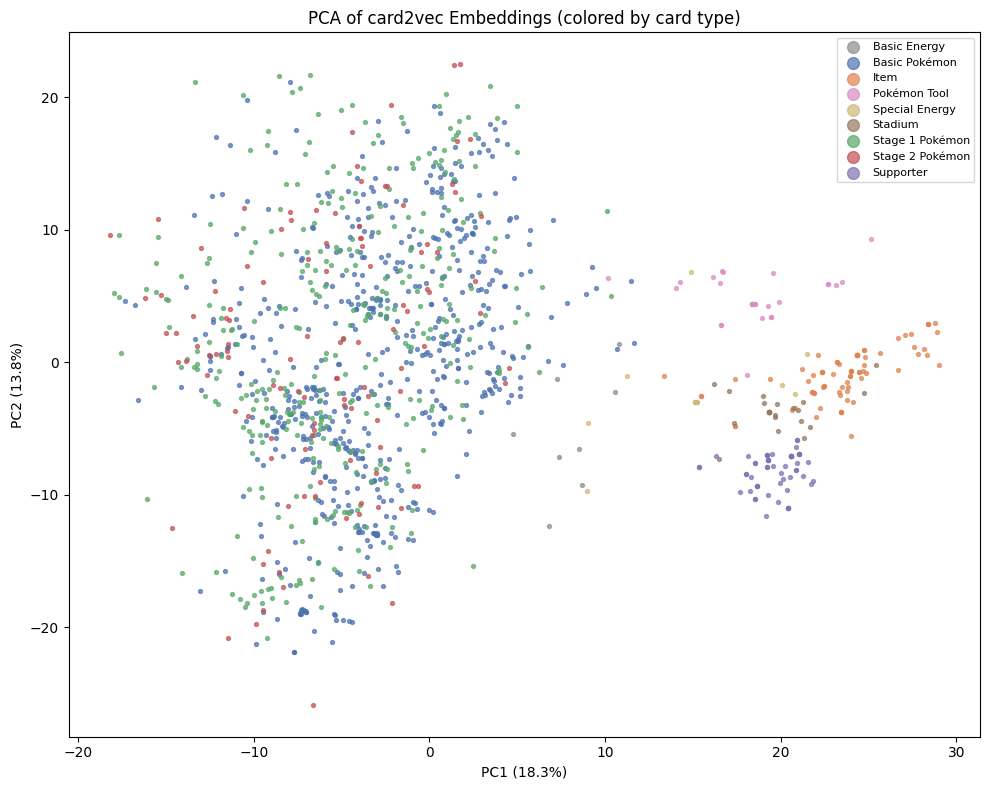

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(embeddings)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.3f}")

# Color by card type / カード種類で色分け
card_types_per_card = [card_rows_map[cid][0]["Stage (Pokémon)/Type (Energy and Trainer)"] for cid in card_ids]
type_set = sorted(set(card_types_per_card))
type_to_color = {
    "Basic Pokémon": "#4C72B0",
    "Stage 1 Pokémon": "#55A868",
    "Stage 2 Pokémon": "#C44E52",
    "Item": "#DD8452",
    "Supporter": "#8172B2",
    "Stadium": "#937860",
    "Pokémon Tool": "#DA8BC3",
    "Basic Energy": "#8C8C8C",
    "Special Energy": "#CCB974",
}

fig, ax = plt.subplots(figsize=(10, 8))
for t in type_set:
    mask = [ct == t for ct in card_types_per_card]
    x = coords_2d[mask, 0]
    y = coords_2d[mask, 1]
    ax.scatter(x, y, label=t, s=8, alpha=0.7, color=type_to_color.get(t, "gray"))

ax.legend(loc="best", fontsize=8, markerscale=3)
ax.set_title("PCA of card2vec Embeddings (colored by card type)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()

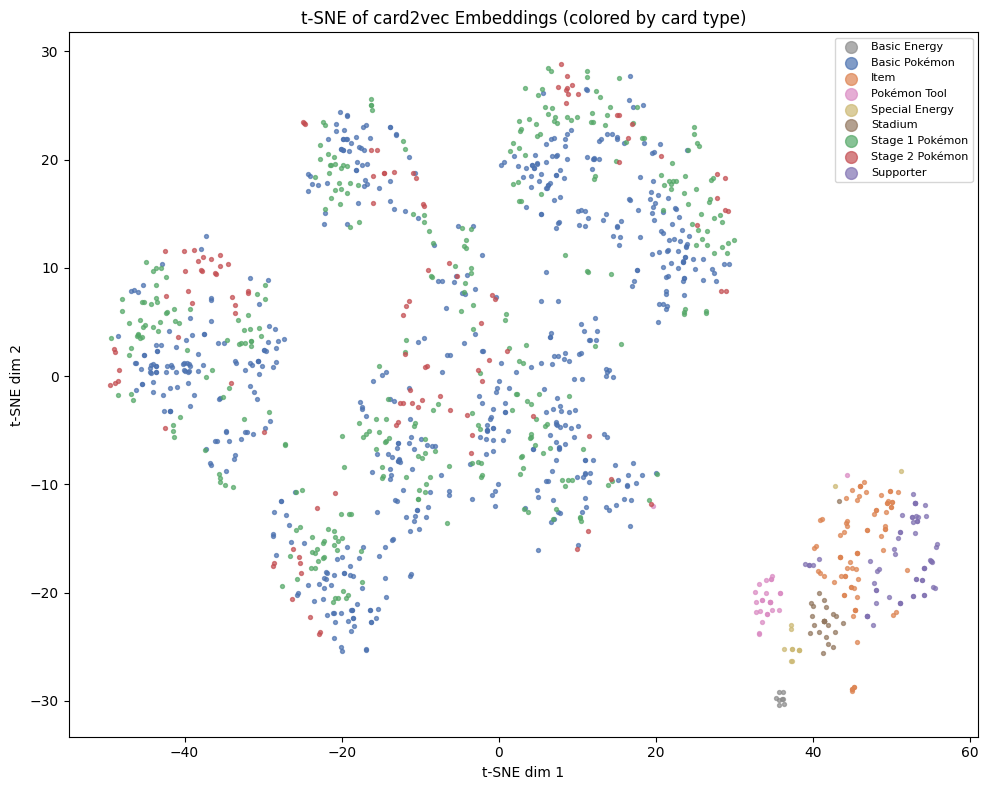

In [15]:
# t-SNE for better cluster visualization / より良いクラスタ可視化のためのt-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
coords_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
for t in type_set:
    mask = [ct == t for ct in card_types_per_card]
    x = coords_tsne[mask, 0]
    y = coords_tsne[mask, 1]
    ax.scatter(x, y, label=t, s=8, alpha=0.7, color=type_to_color.get(t, "gray"))

ax.legend(loc="best", fontsize=8, markerscale=3)
ax.set_title("t-SNE of card2vec Embeddings (colored by card type)")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

In [16]:
# Find most similar cards by cosine similarity / コサイン類似度で最も似たカードを検索
from sklearn.metrics.pairwise import cosine_similarity

card_id_to_idx = {int(cid): i for i, cid in enumerate(card_ids)}
card_id_to_name = {int(r["Card ID"]): r["Card Name"] for r in all_rows}

def find_similar_cards(query_id: int, top_k: int = 5):
    idx = card_id_to_idx[query_id]
    query_vec = embeddings[idx:idx+1]
    sims = cosine_similarity(query_vec, embeddings)[0]
    top_indices = np.argsort(sims)[::-1][1:top_k+1]
    print(f"Query: [{query_id}] {card_id_to_name[query_id]}")
    str_id = str(query_id)
    print(f"  Stage: {card_rows_map[str_id][0]['Stage (Pokémon)/Type (Energy and Trainer)']}")
    print(f"  HP: {card_rows_map[str_id][0]['HP']}, Type: {card_rows_map[str_id][0]['Type']}")
    print(f"Top {top_k} similar cards / 類似カード Top{top_k}:")
    for i in top_indices:
        cid_int = int_card_ids[i]
        row = card_rows_map[str(cid_int)][0]
        print(f"  [{cid_int}] {card_id_to_name[cid_int]} | "
              f"Stage: {row['Stage (Pokémon)/Type (Energy and Trainer)']} | "
              f"HP: {row['HP']} | Type: {row['Type']} | "
              f"sim={sims[i]:.4f}")

# Pick a Pokémon card to query / クエリに使うポケモンカードを選択
pokemon_ids_int = [int(cid) for cid in card_ids
                   if "Pokémon" in card_rows_map[cid][0].get("Stage (Pokémon)/Type (Energy and Trainer)", "")]

print("=" * 70)
find_similar_cards(pokemon_ids_int[100])
print("=" * 70)
find_similar_cards(pokemon_ids_int[200])

Query: [121] Dragapult ex
  Stage: Stage 2 Pokémon
  HP: 320, Type: 竜
Top 5 similar cards / 類似カード Top5:
  [231] Tatsugiri ex | Stage: Basic Pokémon | HP: 160 | Type: 竜 | sim=0.9750
  [302] Salamence ex | Stage: Stage 2 Pokémon | HP: 320 | Type: 竜 | sim=0.9601
  [176] Terapagos ex | Stage: Basic Pokémon | HP: 230 | Type: {C} | sim=0.9592
  [249] Eevee ex | Stage: Basic Pokémon | HP: 200 | Type: {C} | sim=0.9577
  [232] Slaking ex | Stage: Stage 2 Pokémon | HP: 340 | Type: {C} | sim=0.9564
Query: [221] Meowstic
  Stage: Stage 1 Pokémon
  HP: 90, Type: {P}
Top 5 similar cards / 類似カード Top5:
  [542] Mandibuzz | Stage: Stage 1 Pokémon | HP: 110 | Type: {D} | sim=0.9440
  [131] Duskull | Stage: Basic Pokémon | HP: 60 | Type: {P} | sim=0.9400
  [755] Latios | Stage: Basic Pokémon | HP: 130 | Type: 竜 | sim=0.9390
  [1029] Dewgong | Stage: Stage 1 Pokémon | HP: 130 | Type: {W} | sim=0.9385
  [598] Jellicent ex | Stage: Stage 1 Pokémon | HP: 270 | Type: {P} | sim=0.9348


<a id='usage'></a>
## 7. Usage in RL Agent / RLエージェントへの組み込み

### EN

The saved `embeddings_tensor.pt` can be loaded and used in any RL agent as a **frozen card embedding table**. Since index = card_id, lookup is a single tensor index operation — O(1) with no offset arithmetic.

```python
import torch
import torch.nn as nn

# Load the pre-trained embedding table
c2v = torch.load("embeddings_tensor.pt", map_location="cpu")  # Tensor[1268, 64]

# Look up a card embedding by card_id (int)
emb = c2v[card_id]  # Tensor[64]
```

To use inside a PyTorch model with frozen weights:

```python
class MyRLModel(nn.Module):
    def __init__(self, c2v_tensor: torch.Tensor):
        super().__init__()
        num_cards, emb_dim = c2v_tensor.shape
        self.card2vec = nn.Embedding(num_cards, emb_dim, padding_idx=0)
        self.card2vec.weight = nn.Parameter(c2v_tensor.clone(), requires_grad=False)

    def forward(self, card_ids: torch.Tensor):
        return self.card2vec(card_ids)  # [...] -> [..., 64]
```

Setting `requires_grad=False` keeps the embeddings frozen during RL training, using them as a fixed feature extractor.

### JP

保存された `embeddings_tensor.pt` は、任意のRLエージェントに **凍結済みカード埋め込みテーブル** として読み込んで使用できます。インデックス = card_idのため、参照はテンソルの単純なインデックス操作（O(1)）です。

```python
import torch
import torch.nn as nn

# 事前学習済み埋め込みテーブルを読み込む
c2v = torch.load("embeddings_tensor.pt", map_location="cpu")  # Tensor[1268, 64]

# card_id（整数）でカードの埋め込みを取得
emb = c2v[card_id]  # Tensor[64]
```

PyTorchモデル内で重みを凍結して使う場合：

```python
class MyRLModel(nn.Module):
    def __init__(self, c2v_tensor: torch.Tensor):
        super().__init__()
        num_cards, emb_dim = c2v_tensor.shape
        self.card2vec = nn.Embedding(num_cards, emb_dim, padding_idx=0)
        self.card2vec.weight = nn.Parameter(c2v_tensor.clone(), requires_grad=False)

    def forward(self, card_ids: torch.Tensor):
        return self.card2vec(card_ids)  # [...] -> [..., 64]
```

`requires_grad=False` により、RL学習中も埋め込みは固定されたまま特徴抽出器として機能します。

In [17]:
# Verify saved embeddings
saved_dict = torch.load(OUTPUT_DIR / "embeddings.pt", map_location="cpu", weights_only=True)
saved_tensor = torch.load(OUTPUT_DIR / "embeddings_tensor.pt", map_location="cpu", weights_only=True)

sample_id = pokemon_ids_int[0]
print(f"Card: [{sample_id}] {card_id_to_name[sample_id]}")

# Dict lookup (int key)
vec_dict = saved_dict[sample_id]
print(f"Dict lookup  (int key): shape={vec_dict.shape}, first 5 dims={vec_dict[:5].numpy().round(4)}")

# Tensor lookup (index = card_id)
vec_tensor = saved_tensor[sample_id]
print(f"Tensor lookup (index) : shape={vec_tensor.shape}, first 5 dims={vec_tensor[:5].numpy().round(4)}")

print(f"\nMax diff between dict and tensor: {(vec_dict - vec_tensor).abs().max().item():.6f}")
print(f"Index 0 (null/padding) is zero : {saved_tensor[0].abs().max().item() == 0.0}")
print(f"\nembeddings.pt key type: {type(list(saved_dict.keys())[0])}")
print(f"embeddings_tensor.pt shape    : {saved_tensor.shape}  (index = card_id)")

Card: [21] Scrafty
Dict lookup  (int key): shape=torch.Size([64]), first 5 dims=[6.1353 6.8422 9.4979 4.089  8.0894]
Tensor lookup (index) : shape=torch.Size([64]), first 5 dims=[6.1353 6.8422 9.4979 4.089  8.0894]

Max diff between dict and tensor: 0.000000
Index 0 (null/padding) is zero : True

embeddings.pt key type: <class 'int'>
embeddings_tensor.pt shape    : torch.Size([1268, 64])  (index = card_id)


<a id='conclusion'></a>
## 8. Conclusion / まとめ

### EN

We built **card2vec**, a lightweight AutoEncoder that maps each Pokémon TCG card to a 64-dimensional dense vector based on its game-relevant attributes.

**Key takeaways:**
- **148→64 compression** with BCELoss converges quickly (~55k params, under 1 minute on CPU).
- Cards with similar attributes (same stage, type, move structure) naturally cluster together in embedding space, as confirmed by the PCA and t-SNE visualizations.
- The encoder generalizes to **unseen cards** — any card describable by its attributes gets a meaningful embedding without retraining.
- Embeddings are saved in two formats for flexibility:
  - `embeddings.pt` — `dict[int → Tensor(64,)]` for key-based lookup
  - `embeddings_tensor.pt` — dense `Tensor[1268, 64]` for direct card_id indexing (index 0 = null/padding)

---

💬 **I'm relatively new to Kaggle and not very confident in my ML knowledge. If you have any feedback — whether it's a mistake in the approach, a better architecture, or just thoughts on the embedding strategy — please share it in the comments. Discussion is very welcome!**

### JP

ポケモンTCGの各カードをゲーム上の属性に基づいて64次元の密なベクトルにマッピングする軽量AutoEncoder **card2vec** を構築しました。

**ポイント:**
- BCELossによる148→64圧縮。約55kパラメータ、CPUで1分以内に収束。
- PCAおよびt-SNEの可視化で確認できる通り、似た属性を持つカードが埋め込み空間で自然にクラスタリングされる。
- **未学習カード**への汎化が可能。属性で記述できるカードであれば再学習なしで意味ある埋め込みが得られる。
- 2つの形式で保存し、用途に応じて使い分け可能：
  - `embeddings.pt` — `dict[int → Tensor(64,)]`、キー検索向け
  - `embeddings_tensor.pt` — dense `Tensor[1268, 64]`、card_idを直接インデックスとして使用（index 0 = null/padding）

---

💬 **KaggleもMLもまだ勉強中です。設計の判断に自信のない部分も多いので、気になった点や改善のアイデアがあればぜひコメントで教えてください！**

---

<a id='v2'></a>
## Improvements: Regularization & Weighted Loss

> 💬 **EN:** The following section was added as a follow-up experiment based on feedback received in the comments. Thank you for the great suggestions!
>
> 💬 **JP:** 以下の内容は、コメントでいただいたフィードバックをもとに追加で実験した内容です。有益なアドバイスをありがとうございます！

### EN

Based on feedback received on this notebook, two improvements were made to the original AutoEncoder:

1. **Dropout regularization** — With only ~1,300 training samples, there is room for overfitting: the model might find a compression that perfectly reconstructs the training set but results in a fragmented embedding space. Adding Dropout encourages a smoother latent space.

2. **Weighted loss** — In the original implementation, all 148 feature dimensions are treated equally. This means an error in card type (Basic Pokémon vs. Supporter) has the same penalty as an error in a minor keyword flag. We introduce per-group weights to reflect the strategic importance of each feature group.

   > ⚠️ **Note:** The weights below are set manually based on intuition, which is inherently arbitrary. A more principled approach — such as optimizing weights against RL win rate, or switching to a co-occurrence-based approach inspired by word2vec — would be more objective. This is left as a future improvement.

### JP

このノートブックへのフィードバックをもとに、元のAutoEncoderに2つの改善を加えました：

1. **Dropout正則化** — 訓練サンプルが約1,300件と少ないため、過学習の余地があります。過学習すると埋め込み空間が断片的になる可能性があり、Dropoutを追加することで滑らかな潜在空間を促します。

2. **重み付き損失** — 元の実装では148次元すべてを均等に扱っています。そのためカードタイプ（BasicポケモンかSupporterか）の誤りも、マイナーなキーワードフラグの誤りも同じペナルティになってしまいます。各特徴グループの戦略的重要度を反映した重みを導入します。

   > ⚠️ **注意:** 以下の重みは直感をもとに手動で設定しており、恣意的な部分があります。RLの勝率を指標に最適化する、あるいはword2vecの精神に近い共起ベースのアプローチに切り替えるといった、より客観的な方法が望ましいと考えており、今後の改善課題です。

| Feature group | Dims | Weight | Reason |
|---|---|---|---|
| Card type | 9 | **3.0** | Determines play style entirely |
| Rule (ex / ACE SPEC) | 4 | **2.0** | Major game-rule modifier |
| HP | 1 | **2.0** | Core battle stat |
| Pokémon type | 11 | **2.0** | Type matchup is central |
| Damage (×2 moves) | 2 | **2.0** | Core battle stat |
| Weakness | 11 | **1.5** | Important but secondary |
| Retreat cost | 1 | **1.5** | Tactical relevance |
| Energy cost (×2 moves) | 22 | **1.5** | Deck building constraint |
| Category (Ancient/Tera/…) | 7 | **1.0** | Moderate importance |
| Effect keywords (×2 moves) | 80 | **1.0** | Many dims, each minor |

In [18]:
# v2 Model: AutoEncoder with Dropout

DROPOUT = 0.1


class CardAutoEncoderV2(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(FEATURE_DIM, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, LATENT_DIM),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, FEATURE_DIM),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model_v2 = CardAutoEncoderV2()
total_params_v2 = sum(p.numel() for p in model_v2.parameters())
print(f"Total parameters (v2): {total_params_v2:,}  (same architecture, Dropout added)")

Total parameters (v2): 54,740  (same architecture, Dropout added)


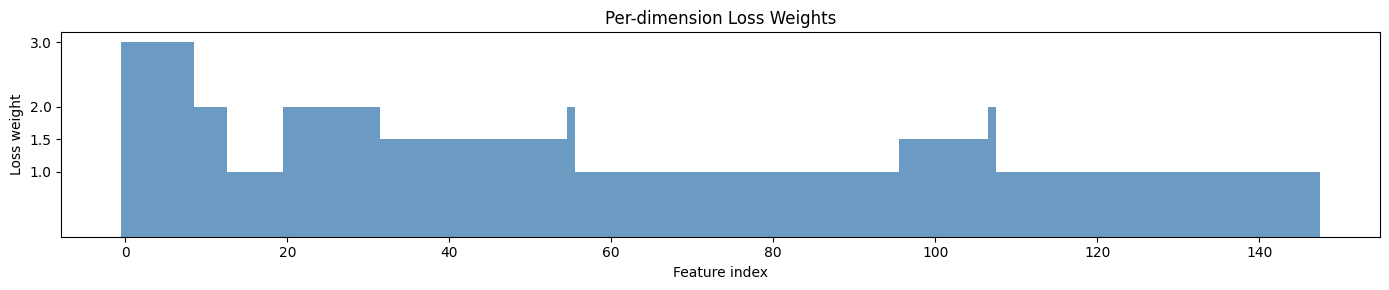

Weight range: [1.0, 3.0]


In [19]:
# Weighted loss

def build_loss_weights() -> torch.Tensor:
    w = torch.ones(FEATURE_DIM)
    idx = 0

    def fill(n, weight):
        nonlocal idx
        w[idx:idx + n] = weight
        idx += n

    fill(len(CARD_TYPES), 3.0)          # card type
    fill(len(RULES), 2.0)               # rule (ex / ACE SPEC)
    fill(len(CATEGORIES), 1.0)          # category
    fill(1, 2.0)                        # HP
    fill(len(POKEMON_TYPES) + 1, 2.0)   # pokemon type
    fill(len(POKEMON_TYPES) + 1, 1.5)   # weakness
    fill(1, 1.5)                        # retreat
    for _ in range(2):                  # move 1 & 2
        fill(len(ENERGY_TYPES), 1.5)    #   energy cost
        fill(1, 2.0)                    #   damage
        fill(len(EFFECT_KEYWORDS), 1.0) #   keywords

    assert idx == FEATURE_DIM, f"Weight index mismatch: {idx} != {FEATURE_DIM}"
    return w


LOSS_WEIGHTS = build_loss_weights()
bce_none = nn.BCELoss(reduction='none')


def weighted_bce_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    per_element = bce_none(pred, target)  # (batch, 148)
    return (per_element * LOSS_WEIGHTS).mean()


# Visualize per-dimension weights
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(FEATURE_DIM), LOSS_WEIGHTS.numpy(), width=1.0, color="steelblue", alpha=0.8)
ax.set_xlabel("Feature index")
ax.set_ylabel("Loss weight")
ax.set_title("Per-dimension Loss Weights")
ax.set_yticks([1.0, 1.5, 2.0, 3.0])
plt.tight_layout()
plt.show()
print(f"Weight range: [{LOSS_WEIGHTS.min().item():.1f}, {LOSS_WEIGHTS.max().item():.1f}]")

In [20]:
# Train v2

EPOCHS_V2 = 200
LR_V2 = 1e-3

model_v2 = CardAutoEncoderV2()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=LR_V2)

loss_history_v2 = []

for epoch in range(1, EPOCHS_V2 + 1):
    model_v2.train()
    total_loss = 0.0
    for (batch,) in loader:
        reconstructed = model_v2(batch)
        loss = weighted_bce_loss(reconstructed, batch)
        optimizer_v2.zero_grad()
        loss.backward()
        optimizer_v2.step()
        total_loss += loss.item() * batch.size(0)
    avg_loss = total_loss / len(dataset)
    loss_history_v2.append(avg_loss)
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3d}/{EPOCHS_V2}  Loss: {avg_loss:.6f}")

print(f"\nFinal loss (v2): {loss_history_v2[-1]:.6f}")

Epoch   1/200  Loss: 0.849428
Epoch  20/200  Loss: 0.121050
Epoch  40/200  Loss: 0.072033
Epoch  60/200  Loss: 0.055107
Epoch  80/200  Loss: 0.045711
Epoch 100/200  Loss: 0.040807
Epoch 120/200  Loss: 0.036576
Epoch 140/200  Loss: 0.034394
Epoch 160/200  Loss: 0.033138
Epoch 180/200  Loss: 0.031614
Epoch 200/200  Loss: 0.030732

Final loss (v2): 0.030732


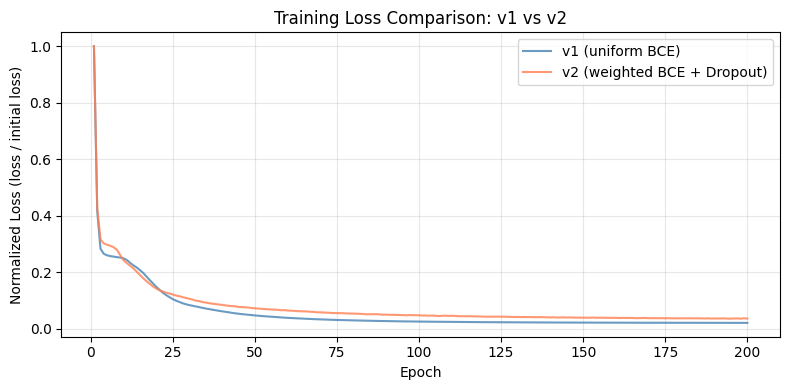

In [21]:
# Loss comparison: v1 vs v2 / 損失の比較
# Note: v1 uses uniform BCELoss, v2 uses weighted BCELoss — absolute values are not directly comparable.
# We compare the learning curves normalized to their own starting loss.
# 注意: v1は均一BCELoss、v2は重み付きBCELossのため絶対値は比較不可。
# それぞれの初期損失で正規化した学習曲線を比較します。

v1_norm = [l / loss_history[0] for l in loss_history]
v2_norm = [l / loss_history_v2[0] for l in loss_history_v2]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), v1_norm, label="v1 (uniform BCE)", color="steelblue", alpha=0.8)
ax.plot(range(1, EPOCHS_V2 + 1), v2_norm, label="v2 (weighted BCE + Dropout)", color="coral", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Normalized Loss (loss / initial loss)")
ax.set_title("Training Loss Comparison: v1 vs v2")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Extract v2 embeddings and compare similarity results

model_v2.eval()
with torch.no_grad():
    embeddings_v2 = model_v2.encoder(tensor).numpy()

print(f"Embeddings v2 shape: {embeddings_v2.shape}")


def find_similar_cards_v2(query_id: int, top_k: int = 5):
    idx = card_id_to_idx[query_id]
    sims = cosine_similarity(embeddings_v2[idx:idx+1], embeddings_v2)[0]
    top_indices = np.argsort(sims)[::-1][1:top_k+1]
    print(f"Query: [{query_id}] {card_id_to_name[query_id]}")
    str_id = str(query_id)
    print(f"  Stage: {card_rows_map[str_id][0]['Stage (Pokémon)/Type (Energy and Trainer)']}")
    print(f"  HP: {card_rows_map[str_id][0]['HP']}, Type: {card_rows_map[str_id][0]['Type']}")
    print(f"Top {top_k} similar (v2):")
    for i in top_indices:
        cid_int = int_card_ids[i]
        row = card_rows_map[str(cid_int)][0]
        print(f"  [{cid_int}] {card_id_to_name[cid_int]} | "
              f"Stage: {row['Stage (Pokémon)/Type (Energy and Trainer)']} | "
              f"HP: {row['HP']} | Type: {row['Type']} | sim={sims[i]:.4f}")


print("=" * 70)
find_similar_cards(pokemon_ids_int[100])    # v1
print()
find_similar_cards_v2(pokemon_ids_int[100]) # v2
print("=" * 70)
find_similar_cards(pokemon_ids_int[200])    # v1
print()
find_similar_cards_v2(pokemon_ids_int[200]) # v2

Embeddings v2 shape: (1267, 64)
Query: [121] Dragapult ex
  Stage: Stage 2 Pokémon
  HP: 320, Type: 竜
Top 5 similar cards / 類似カード Top5:
  [231] Tatsugiri ex | Stage: Basic Pokémon | HP: 160 | Type: 竜 | sim=0.9750
  [302] Salamence ex | Stage: Stage 2 Pokémon | HP: 320 | Type: 竜 | sim=0.9601
  [176] Terapagos ex | Stage: Basic Pokémon | HP: 230 | Type: {C} | sim=0.9592
  [249] Eevee ex | Stage: Basic Pokémon | HP: 200 | Type: {C} | sim=0.9577
  [232] Slaking ex | Stage: Stage 2 Pokémon | HP: 340 | Type: {C} | sim=0.9564

Query: [121] Dragapult ex
  Stage: Stage 2 Pokémon
  HP: 320, Type: 竜
Top 5 similar (v2):
  [231] Tatsugiri ex | Stage: Basic Pokémon | HP: 160 | Type: 竜 | sim=0.9556
  [153] Cinderace ex | Stage: Stage 2 Pokémon | HP: 320 | Type: {R} | sim=0.9481
  [176] Terapagos ex | Stage: Basic Pokémon | HP: 230 | Type: {C} | sim=0.9247
  [302] Salamence ex | Stage: Stage 2 Pokémon | HP: 320 | Type: 竜 | sim=0.9243
  [232] Slaking ex | Stage: Stage 2 Pokémon | HP: 340 | Type: {C} | 

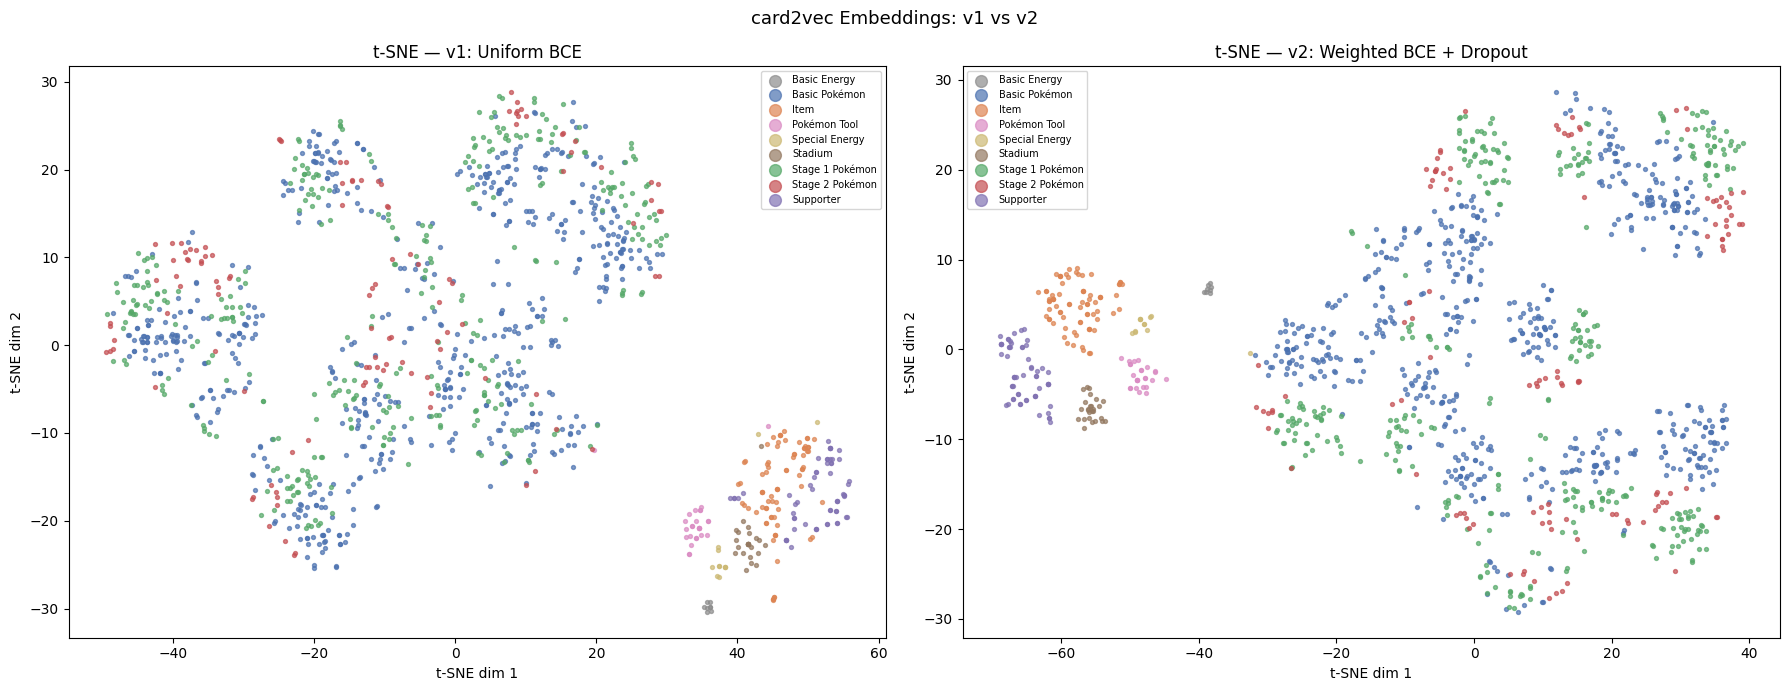

In [23]:
# t-SNE: v1 vs v2 side by side / t-SNEの並列比較

tsne_v2 = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
coords_tsne_v2 = tsne_v2.fit_transform(embeddings_v2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, coords, title in [
    (axes[0], coords_tsne, "v1: Uniform BCE"),
    (axes[1], coords_tsne_v2, "v2: Weighted BCE + Dropout"),
]:
    for t in type_set:
        mask = [ct == t for ct in card_types_per_card]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=t, s=8, alpha=0.7, color=type_to_color.get(t, "gray"))
    ax.set_title(f"t-SNE — {title}")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.legend(loc="best", fontsize=7, markerscale=3)

plt.suptitle("card2vec Embeddings: v1 vs v2", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# Save v2 embeddings / v2埋め込みを保存

embedding_dict_v2 = {cid: torch.from_numpy(embeddings_v2[i]) for i, cid in enumerate(int_card_ids)}
torch.save(embedding_dict_v2, OUTPUT_DIR / "embeddings_v2.pt")

dense_v2 = torch.zeros(max_id + 1, LATENT_DIM)
for cid, emb in embedding_dict_v2.items():
    dense_v2[cid] = emb
torch.save(dense_v2, OUTPUT_DIR / "embeddings_tensor_v2.pt")

torch.save(model_v2.state_dict(), OUTPUT_DIR / "card_autoencoder_v2.pth")

print(f"Saved embeddings_v2.pt        : dict[int -> Tensor({LATENT_DIM},)], {len(embedding_dict_v2)} cards")
print(f"Saved embeddings_tensor_v2.pt : Tensor({dense_v2.shape[0]}, {LATENT_DIM}), index=card_id (0=null)")
print(f"Saved card_autoencoder_v2.pth : model weights")

Saved embeddings_v2.pt        : dict[int -> Tensor(64,)], 1267 cards
Saved embeddings_tensor_v2.pt : Tensor(1268, 64), index=card_id (0=null)
Saved card_autoencoder_v2.pth : model weights


---

<a id='w2v'></a>
## Co-occurrence Embedding (inspired by word2vec)

> 💬 **EN:** The following section was added as a follow-up experiment based on feedback received in the comments. Thank you for the great suggestions!
>
> 💬 **JP:** 以下の内容は、コメントでいただいたフィードバックをもとに追加で実験した内容です。有益なアドバイスをありがとうございます！

### EN

The AutoEncoder approach encodes cards from their attributes ("cards that look similar → close embeddings"). The co-occurrence approach instead captures **how cards are actually used together**.

Two embeddings are built from battle logs:

1. **Deck embedding** — Cards that appear together in the same deck are embedded close to each other. Captures deck-building synergy.
2. **Combo embedding** — Cards that appear on the field at the same time are embedded close to each other. Captures in-game play patterns.

> ⚠️ **Limitation — fallback space mismatch:** Cards that never appear in battle logs cannot get a co-occurrence embedding. We fall back to the AutoEncoder (v2) embedding for such cards. However, the Word2Vec and AutoEncoder embeddings are trained independently and live in completely different vector spaces (different origin, scale, and orientation). This means similarity comparisons between a Word2Vec card and a fallback card are not meaningful.
>
> In practice, this is unlikely to cause problems in this competition: cards actively used in RL training are drawn from real decks, so they almost always appear in battle logs and receive a proper Word2Vec embedding. Fallback cards are typically low-frequency or newly released cards that rarely appear in games anyway.

### JP

AutoEncoderは「属性が似ているカード → 近い埋め込み」でしたが、共起ベースのアプローチは**実際にどう一緒に使われるか**を捉えます。

バトルログから2種類の埋め込みを構築します：

1. **Deck embedding** — 同じデッキに一緒に採用されるカードを近くに配置。デッキ構築の相性を捉える。
2. **Combo embedding** — 同じゲームでフィールドに同時に出るカードを近くに配置。実戦でのプレイパターンを捉える。

> ⚠️ **制約 — fallbackによる空間の不一致:** バトルログに一度も登場しないカードは共起埋め込みを作れません。そのようなカードにはAutoEncoder（v2）の埋め込みをfallbackとして使用します。ただし、Word2VecとAutoEncoderは独立に学習されており、埋め込み空間（原点・スケール・方向）が全く異なります。そのため、Word2Vecで得たカードとfallbackカードの類似度計算は意味のある値になりません。
>
> 実用上は、このコンペでの影響は限定的と考えられます。RLエージェントが学習に使うカードは実際のデッキから引かれるため、バトルログに登場する可能性が高く、ほぼWord2Vec埋め込みが割り当てられます。fallbackが発生するのは出現頻度の低いカードや新弾カードが主であり、ゲーム中に参照されることはまれです。

In [25]:
from gensim.models import Word2Vec
print(f"gensim version: {__import__('gensim').__version__}")

gensim version: 4.4.0


In [26]:
# Parse battle logs
import json

episode_dirs = [
    Path(d)
    for d in glob.glob("/kaggle/input/datasets/organizations/kaggle/pokemon-tcg-ai-battle-episodes-*/**", recursive=True)
    if Path(d).is_dir()
]

# Local path (commented out — do not use on Kaggle)
# episode_dirs = sorted(Path("/path/to/local/episodes").iterdir())

DECK_SENTENCES_CACHE = OUTPUT_DIR / "deck_sentences.json"
COMBO_SENTENCES_CACHE = OUTPUT_DIR / "combo_sentences.json"

# Load from cache if available
if DECK_SENTENCES_CACHE.exists() and COMBO_SENTENCES_CACHE.exists():
    with open(DECK_SENTENCES_CACHE) as f:
        deck_sentences = json.load(f)
    with open(COMBO_SENTENCES_CACHE) as f:
        combo_sentences = json.load(f)
    print(f"Loaded from cache.")
    print(f"Deck sentences : {len(deck_sentences):,}")
    print(f"Combo sentences: {len(combo_sentences):,}")
else:
    def extract_field_ids(obs: dict) -> list[int]:
        """Extract card IDs of the field Pokémon for one player."""
        ids = []
        try:
            for player in obs["current"]["players"]:
                for poke in (player.get("active") or []):
                    if poke and (cid := poke.get("id")):
                        ids.append(cid)
                for poke in (player.get("bench") or []):
                    if poke and (cid := poke.get("id")):
                        ids.append(cid)
        except (KeyError, TypeError):
            pass
        return ids

    deck_sentences = []
    combo_sentences = []
    n_episodes = 0

    for date_dir in episode_dirs:
        json_paths = sorted(date_dir.glob("*.json"))
        n_files = len(json_paths)
        print(f"[{date_dir.name}] {n_files} files ...", flush=True)

        for i, json_path in enumerate(json_paths):
            try:
                with open(json_path, encoding="utf-8") as f:
                    ep = json.load(f)
            except Exception:
                continue

            steps = ep.get("steps", [])
            if len(steps) < 3:
                continue

            n_episodes += 1

            # Deck sentences: deduplicated card list per player deck
            for p in range(2):
                deck = steps[1][p].get("action", [])
                if isinstance(deck, list) and len(deck) == 60:
                    unique_deck = list(dict.fromkeys(deck))  # preserve order, remove duplicates
                    deck_sentences.append([str(cid) for cid in unique_deck])

            # Combo sentences: per-player field sequence throughout the game.
            # Mixing both players into one sequence would create false co-occurrences
            # between cards that appeared at the boundary of consecutive turns.
            player_sequences: list[list[str]] = [[], []]
            for step_idx in range(2, len(steps)):
                for p in range(2):
                    obs = steps[step_idx][p].get("observation", {})
                    if obs:
                        player_sequences[p].extend(
                            [str(cid) for cid in extract_field_ids(obs)]
                        )
            for seq in player_sequences:
                if seq:
                    combo_sentences.append(seq)

            if (i + 1) % 500 == 0:
                print(f"  {i + 1}/{n_files} files  episodes={n_episodes:,}", flush=True)

        print(f"  done: {n_files} files  episodes={n_episodes:,}", flush=True)

    print(f"\nTotal episodes : {n_episodes:,}")
    print(f"Deck sentences : {len(deck_sentences):,}")
    print(f"Combo sentences: {len(combo_sentences):,}")

    with open(DECK_SENTENCES_CACHE, "w") as f:
        json.dump(deck_sentences, f)
    with open(COMBO_SENTENCES_CACHE, "w") as f:
        json.dump(combo_sentences, f)
    print(f"\nSaved to {DECK_SENTENCES_CACHE} and {COMBO_SENTENCES_CACHE}")

deck_vocab = set(w for s in deck_sentences for w in s)
combo_vocab = set(w for s in combo_sentences for w in s)
print(f"Deck vocab size : {len(deck_vocab)} unique card IDs")
print(f"Combo vocab size: {len(combo_vocab)} unique card IDs")

[pokemon-tcg-ai-battle-episodes-2026-06-18] 6532 files ...
  500/6532 files  episodes=500
  1000/6532 files  episodes=1,000
  1500/6532 files  episodes=1,500
  2000/6532 files  episodes=2,000
  2500/6532 files  episodes=2,500
  3000/6532 files  episodes=3,000
  3500/6532 files  episodes=3,500
  4000/6532 files  episodes=4,000
  4500/6532 files  episodes=4,500
  5000/6532 files  episodes=5,000
  5500/6532 files  episodes=5,500
  6000/6532 files  episodes=6,000
  6500/6532 files  episodes=6,500
  done: 6532 files  episodes=6,532

Total episodes : 6,532
Deck sentences : 13,064
Combo sentences: 13,064

Saved to deck_sentences.json and combo_sentences.json
Deck vocab size : 296 unique card IDs
Combo vocab size: 151 unique card IDs


In [27]:
# Train Word2Vec models
import time

W2V_EPOCHS = 20

# Deck embedding: large window to treat the full deck as context
t0 = time.time()
model_deck_w2v = Word2Vec(
    sentences=deck_sentences,
    vector_size=LATENT_DIM,
    window=30,
    min_count=1,
    sg=1,          # Skip-gram
    workers=4,
    epochs=W2V_EPOCHS,
    seed=42,
)
print(f"Deck  Word2Vec vocab: {len(model_deck_w2v.wv)} cards  ({time.time() - t0:.1f}s)")

# Combo embedding: small window to capture temporal co-occurrence on the field
# Significantly slower than deck: each sentence spans a full game (~140 steps x 6 cards),
# producing far more skip-gram pairs than the short deck sentences.
t0 = time.time()
model_combo_w2v = Word2Vec(
    sentences=combo_sentences,
    vector_size=LATENT_DIM,
    window=5,
    min_count=1,
    sg=1,
    workers=4,
    epochs=W2V_EPOCHS,
    seed=42,
)
print(f"Combo Word2Vec vocab: {len(model_combo_w2v.wv)} cards  ({time.time() - t0:.1f}s)")

Deck  Word2Vec vocab: 296 cards  (5.0s)
Combo Word2Vec vocab: 151 cards  (143.7s)


In [28]:
# Extract embeddings with AutoEncoder v2 fallback

def build_w2v_embeddings(
    w2v_model: Word2Vec,
    card_ids: list[int],
    fallback_embeddings: np.ndarray,
) -> tuple[np.ndarray, int]:
    """Build embedding matrix from Word2Vec. Falls back to AutoEncoder for unseen cards."""
    result = np.zeros((len(card_ids), LATENT_DIM), dtype=np.float32)
    n_fallback = 0
    for i, cid in enumerate(card_ids):
        if str(cid) in w2v_model.wv:
            result[i] = w2v_model.wv[str(cid)]
        else:
            result[i] = fallback_embeddings[i]
            n_fallback += 1
    return result, n_fallback


embeddings_deck, n_fb_deck = build_w2v_embeddings(model_deck_w2v, int_card_ids, embeddings_v2)
embeddings_combo, n_fb_combo = build_w2v_embeddings(model_combo_w2v, int_card_ids, embeddings_v2)

print(f"Deck  embeddings shape: {embeddings_deck.shape}  (fallback: {n_fb_deck} cards)")
print(f"Combo embeddings shape: {embeddings_combo.shape}  (fallback: {n_fb_combo} cards)")

Deck  embeddings shape: (1267, 64)  (fallback: 971 cards)
Combo embeddings shape: (1267, 64)  (fallback: 1116 cards)


In [29]:
# Similar card comparison: AutoEncoder vs Deck vs Combo

def find_similar(query_id: int, emb_matrix: np.ndarray, label: str, top_k: int = 5):
    idx = card_id_to_idx[query_id]
    sims = cosine_similarity(emb_matrix[idx:idx+1], emb_matrix)[0]
    top_indices = np.argsort(sims)[::-1][1:top_k+1]
    print(f"  [{label}]")
    for i in top_indices:
        cid_int = int_card_ids[i]
        row = card_rows_map[str(cid_int)][0]
        print(f"    [{cid_int}] {card_id_to_name[cid_int]} | "
              f"{row['Stage (Pokémon)/Type (Energy and Trainer)']} | "
              f"HP:{row['HP']} | sim={sims[i]:.4f}")


for query_id in [pokemon_ids_int[100], pokemon_ids_int[200]]:
    print("=" * 70)
    print(f"Query: [{query_id}] {card_id_to_name[query_id]}")
    find_similar(query_id, embeddings, "AutoEncoder (v1)")
    find_similar(query_id, embeddings_deck, "Deck co-occurrence")
    find_similar(query_id, embeddings_combo, "Combo co-occurrence")

Query: [121] Dragapult ex
  [AutoEncoder (v1)]
    [231] Tatsugiri ex | Basic Pokémon | HP:160 | sim=0.9750
    [302] Salamence ex | Stage 2 Pokémon | HP:320 | sim=0.9601
    [176] Terapagos ex | Basic Pokémon | HP:230 | sim=0.9592
    [249] Eevee ex | Basic Pokémon | HP:200 | sim=0.9577
    [232] Slaking ex | Stage 2 Pokémon | HP:340 | sim=0.9564
  [Deck co-occurrence]
    [120] Drakloak | Stage 1 Pokémon | HP:90 | sim=0.6343
    [119] Dreepy | Basic Pokémon | HP:70 | sim=0.6113
    [131] Duskull | Basic Pokémon | HP:60 | sim=0.6025
    [1027] Turtonator | Basic Pokémon | HP:120 | sim=0.5959
    [132] Dusclops | Stage 1 Pokémon | HP:90 | sim=0.5843
  [Combo co-occurrence]
    [120] Drakloak | Stage 1 Pokémon | HP:90 | sim=0.8478
    [1071] Meowth ex | Basic Pokémon | HP:170 | sim=0.6025
    [184] Latias ex | Basic Pokémon | HP:210 | sim=0.5864
    [235] Budew | Basic Pokémon | HP:30 | sim=0.5103
    [119] Dreepy | Basic Pokémon | HP:70 | sim=0.4696
Query: [221] Meowstic
  [AutoEncoder

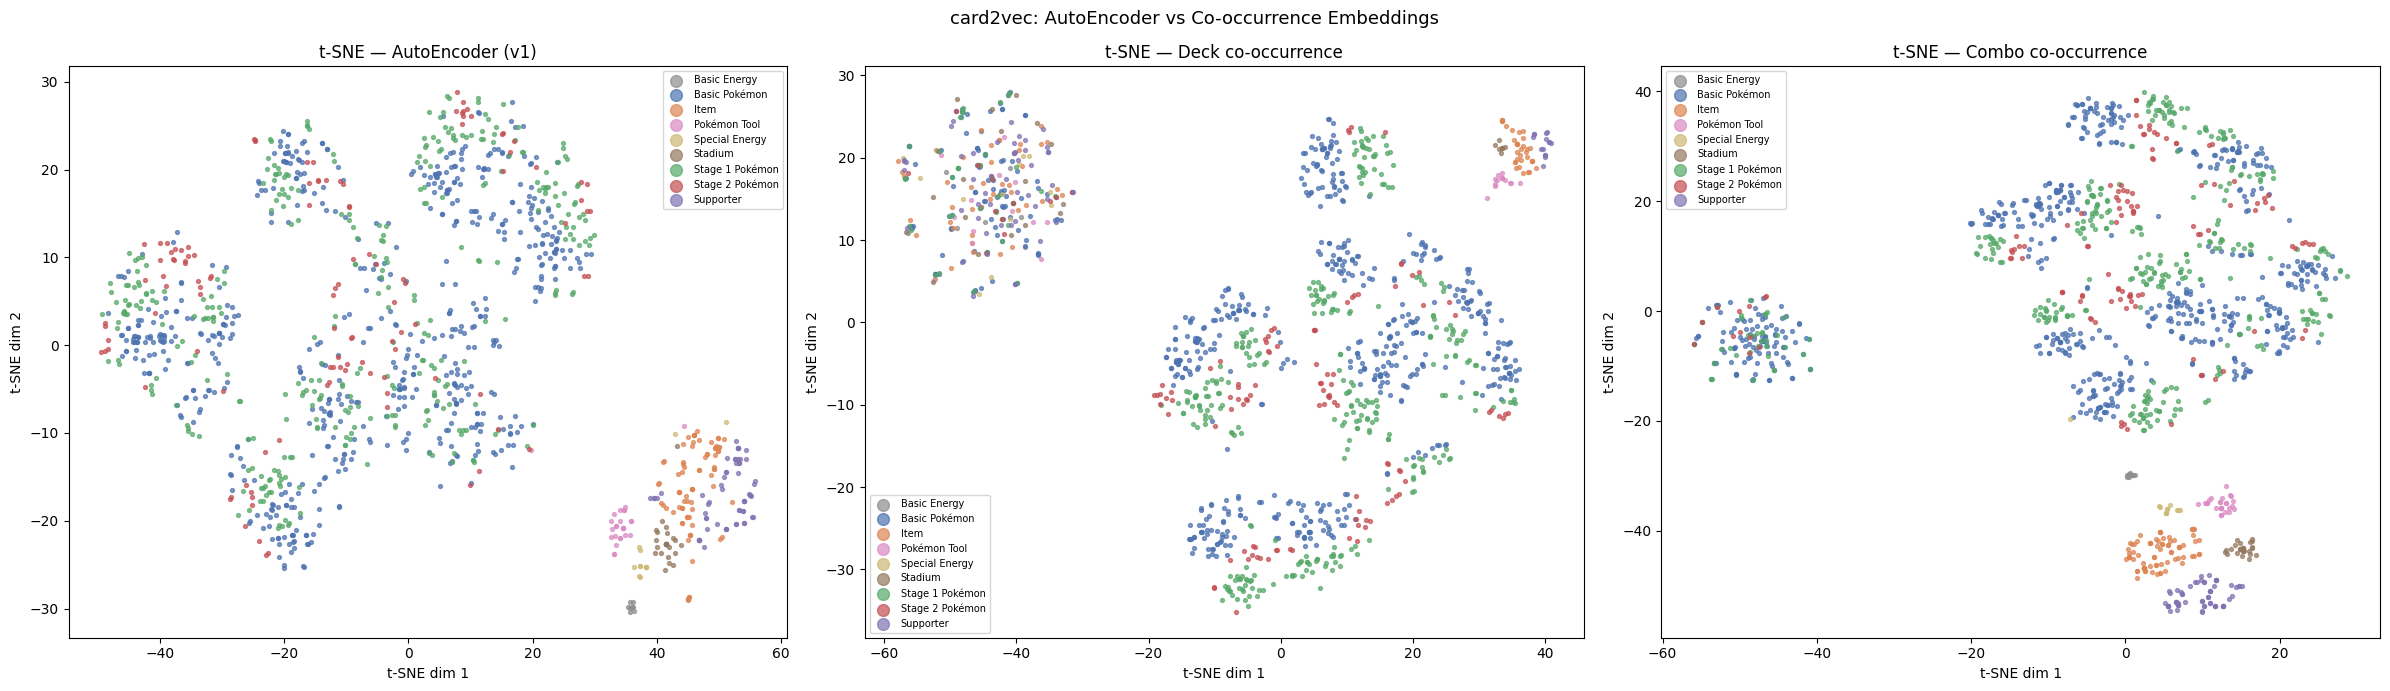

In [30]:
# t-SNE: AutoEncoder vs Deck vs Combo

tsne_deck = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
tsne_combo = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
coords_deck = tsne_deck.fit_transform(embeddings_deck)
coords_combo = tsne_combo.fit_transform(embeddings_combo)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, coords, title in [
    (axes[0], coords_tsne, "AutoEncoder (v1)"),
    (axes[1], coords_deck, "Deck co-occurrence"),
    (axes[2], coords_combo, "Combo co-occurrence"),
]:
    for t in type_set:
        mask = [ct == t for ct in card_types_per_card]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=t, s=8, alpha=0.7, color=type_to_color.get(t, "gray"))
    ax.set_title(f"t-SNE — {title}")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.legend(loc="best", fontsize=7, markerscale=3)

plt.suptitle("card2vec: AutoEncoder vs Co-occurrence Embeddings", fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
# Save co-occurrence embeddings

for name, emb_array in [("deck", embeddings_deck), ("combo", embeddings_combo)]:
    emb_dict = {cid: torch.from_numpy(emb_array[i]) for i, cid in enumerate(int_card_ids)}
    torch.save(emb_dict, OUTPUT_DIR / f"embeddings_{name}.pt")

    dense = torch.zeros(max_id + 1, LATENT_DIM)
    for cid, emb in emb_dict.items():
        dense[cid] = emb
    torch.save(dense, OUTPUT_DIR / f"embeddings_tensor_{name}.pt")

    print(f"Saved embeddings_{name}.pt        : {len(emb_dict)} cards")
    print(f"Saved embeddings_tensor_{name}.pt : Tensor({dense.shape[0]}, {LATENT_DIM})")

Saved embeddings_deck.pt        : 1267 cards
Saved embeddings_tensor_deck.pt : Tensor(1268, 64)
Saved embeddings_combo.pt        : 1267 cards
Saved embeddings_tensor_combo.pt : Tensor(1268, 64)


---

<a id='summary'></a>
## Summary / まとめ

### EN

This notebook explored three approaches to building card embeddings for Pokémon TCG:

| Approach | Method | Strength | Limitation |
|---|---|---|---|
| **AutoEncoder (v1)** | Reconstruct card attributes (148-dim → 64-dim) | Covers all cards; no battle data needed | Captures only attribute similarity |
| **AutoEncoder (v2)** | v1 + Dropout + weighted loss | Smoother latent space; strategically important features penalized more | Weights are manually tuned |
| **Deck co-occurrence** | Word2Vec on deck card lists (window=30) | Captures deck-building synergy from real games | Cards absent from logs fall back to AutoEncoder |
| **Combo co-occurrence** | Word2Vec on per-player field sequences (window=5) | Captures actual in-game play patterns | Same fallback limitation |

**Saved files:**

| File | Description |
|---|---|
| `embeddings_tensor.pt` | AutoEncoder v1 — `Tensor[N, 64]`, index = card_id |
| `embeddings_tensor_v2.pt` | AutoEncoder v2 — same format |
| `embeddings_tensor_deck.pt` | Deck co-occurrence — same format |
| `embeddings_tensor_combo.pt` | Combo co-occurrence — same format |

All tensors share the same shape and index convention (`row 0 = null/padding`), so they are drop-in replaceable in any RL agent.

> ⚠️ **Note on co-occurrence embeddings:** The Deck and Combo embeddings in this notebook were built from the 2026-06-18 battle log dataset only. For more reliable embeddings, they should be retrained on the full multi-date dataset, which would increase vocabulary coverage and reduce bias toward the meta of a single day.

### JP

このノートブックでは、ポケモンTCGのカード埋め込みを構築する3つのアプローチを検討しました：

| アプローチ | 手法 | 強み | 制約 |
|---|---|---|---|
| **AutoEncoder (v1)** | カード属性を再構成（148次元→64次元） | 全カードに対応；バトルデータ不要 | 属性の類似度のみを反映 |
| **AutoEncoder (v2)** | v1 + Dropout + 重み付き損失 | より滑らかな潜在空間；重要な特徴量に高いペナルティ | 重みは手動チューニング |
| **Deck共起** | デッキ内カードリストでWord2Vec（window=30） | 実ゲームのデッキ構築の相性を反映 | ログ未登場カードはAutoEncoderにフォールバック |
| **Combo共起** | プレイヤーごとのフィールド列でWord2Vec（window=5） | 実戦でのプレイパターンを反映 | 同上 |

**保存ファイル:**

| ファイル | 内容 |
|---|---|
| `embeddings_tensor.pt` | AutoEncoder v1 — `Tensor[N, 64]`、インデックス = card_id |
| `embeddings_tensor_v2.pt` | AutoEncoder v2 — 同形式 |
| `embeddings_tensor_deck.pt` | Deck共起 — 同形式 |
| `embeddings_tensor_combo.pt` | Combo共起 — 同形式 |

全テンソルは同じshapeとインデックス規約（`row 0 = null/padding`）を持つため、RLエージェントで差し替えて比較できます。

> ⚠️ **共起埋め込みについての注意:** このノートブックのDeck・Combo埋め込みは 2026-06-18 のバトルログのみを使用して構築しています。より信頼性の高い埋め込みを得るには、複数日分のデータで再学習する必要があります。データが増えることでボキャブラリのカバレッジが向上し、特定日のメタへの偏りも軽減されます。

---

💬 **EN:** If you have thoughts on which embedding strategy works best in practice, or ideas for further improvements, please share in the comments!

💬 **JP:** どのアプローチが実際に有効か、あるいは改善のアイデアがあれば、ぜひコメントで教えてください！